# How to reconstruct harmonic tides having the harmonic constituents?

1. If you have ta time series of water level (or pressure), it is stragithforward to use Utide (or Ttide) to do the harmonic analysis and reconstruct the tide level... the Utide generates a 'bunch' of 'coefficients' which are straighforeward...
2. However, if you have the tidal constituents... it is not so easy... let´s see how!

Schettini, 17-Dec-2025

## Afterthoughts
1. To reconstruct the harmonic tidal level having only the harmonics data, it is enough to create a 'dummy' bunch and insert the things in the right places, like below
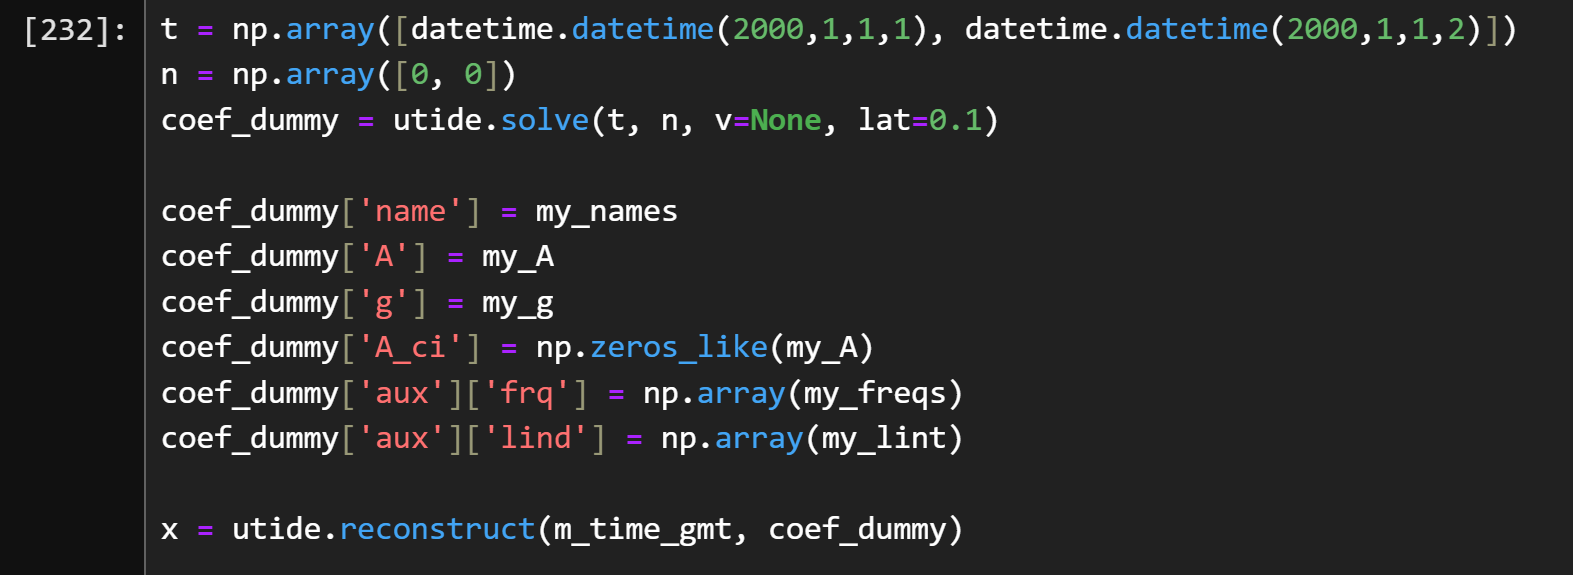

In [192]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle
import scipy.signal as signal
import utide
import datetime
import copy
import pickle

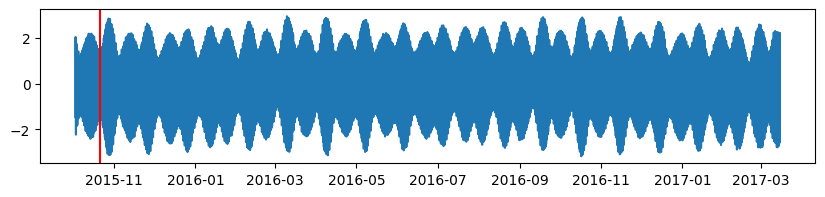

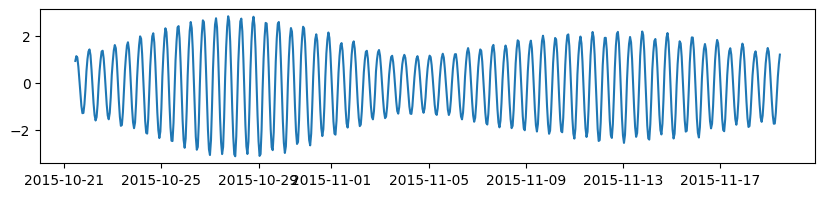

In [193]:
# data from the Para mooring... 
# junta = [time, depth, z_sig, v1_r, v2_r]
with open('ADCP_rdz_sigma.pkl', 'rb') as io:
    x = pickle.load(io)

time_all = x[0]
depth = x[1]
waterlevel = depth - np.mean(depth)
waterlevel = signal.detrend(waterlevel)

# select 29 days
time = time_all[450:450+int(24*29)+1]
h = waterlevel[450:450+int(24*29)+1]


fig, ax = plt.subplots(figsize=(10,2))
ax.plot(time_all, waterlevel)
ax.axvline(time_all[450], color='r')
fig, ax = plt.subplots(figsize=(10,2))
ax.plot(time, h)

# Doing the harmonic analysis with Utide
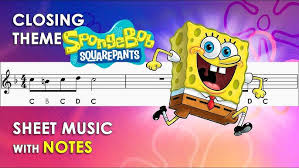

In [194]:
# we need use the tide referenced to Greenwich! UTC!
time_gmt = time + datetime.timedelta(hours = 3)

# coef = utide.solve(time_gmt, waterlevel, v=None, lat = -0.5, constit = constituents )
coef = utide.solve(time_gmt, h, v=None, lat = -0.5)

solve: matrix prep ... solution ... done.


### 'coef' is a bunch, which is a sort of dictionary created using 'class' stuff... what I don´t know much about!

In [195]:
type(coef)

utide.utilities.Bunch

In [196]:
coef.keys()

dict_keys(['name', 'aux', 'nR', 'nNR', 'nI', 'weights', 'A', 'g', 'mean', 'slope', 'g_ci', 'A_ci', 'diagn', 'PE', 'SNR'])

## Reconstructing the harmonic tides (predicting!)
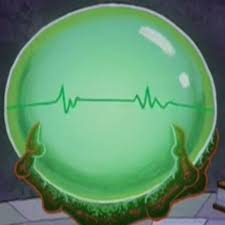

prep/calcs ... done.


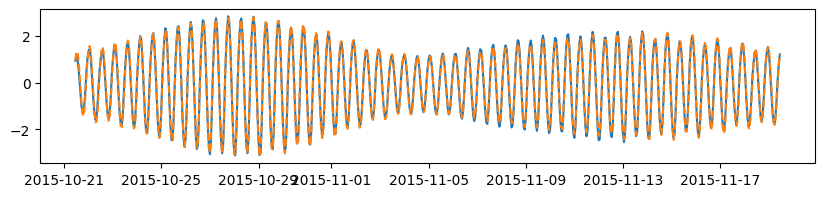

In [197]:
x = utide.reconstruct(time_gmt, coef)

h_harmonic = x['h']

fig, ax = plt.subplots(figsize=(10,2))
ax.plot(time, h)
ax.plot(time, h_harmonic, '--')

# Pretty neat... 
1. However, if I don´t have the time series, and have the harmonic constituents from somewhere and need to use the Utide?
2. There is a thread in the GitHub about this, but they don´t give the solution!!
https://github.com/wesleybowman/UTide/issues/39
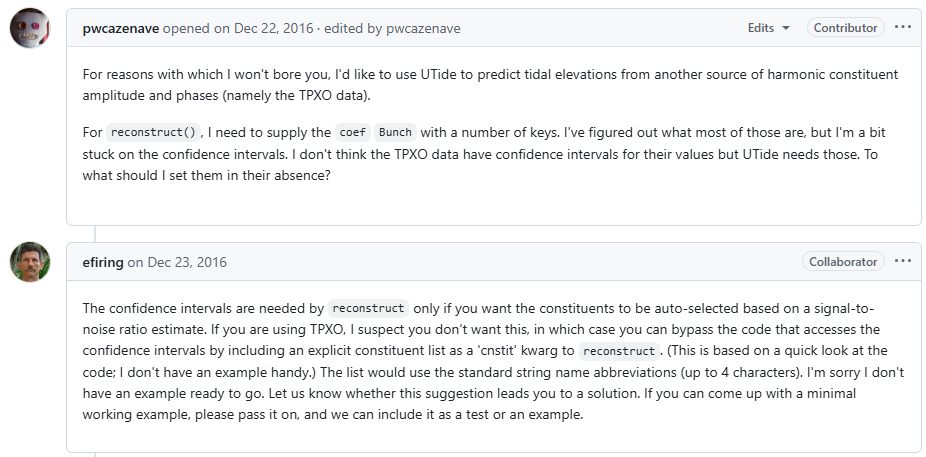

### Coef is a structure, and 'aux' is a sub-structure...

In [198]:
coef.keys()

dict_keys(['name', 'aux', 'nR', 'nNR', 'nI', 'weights', 'A', 'g', 'mean', 'slope', 'g_ci', 'A_ci', 'diagn', 'PE', 'SNR'])

In [199]:
coef['aux'].keys()

dict_keys(['frq', 'lind', 'reftime', 'opt', 'lat'])

In [200]:
coef['name']

array(['M2', 'S2', 'N2', 'K1', 'O1', 'M4', 'ETA2', 'MS4', 'M6', 'MN4',
       '2MS6', 'MK3', 'Q1', '2MN6', 'M3', 'MO3', 'MSF', 'OO1', 'UPS1',
       'M8', 'J1', 'S4', '2Q1', '2SM6', 'SK3', '3MK7', 'NO1', '2SK5',
       '2MK5'], dtype=object)

In [201]:
coef['A']

array([1.85182265e+00, 5.99171637e-01, 3.89001780e-01, 1.03498715e-01,
       9.21875727e-02, 7.11831032e-02, 5.26727407e-02, 3.84334226e-02,
       3.54402820e-02, 3.02425324e-02, 2.72960298e-02, 2.23203591e-02,
       2.12537408e-02, 2.07140023e-02, 2.01018769e-02, 1.87748343e-02,
       1.53562265e-02, 1.20751787e-02, 1.09113260e-02, 9.89208511e-03,
       5.82773863e-03, 4.69369540e-03, 4.67038553e-03, 4.08635445e-03,
       4.00782073e-03, 3.12765378e-03, 2.80680935e-03, 1.81799216e-03,
       1.50821900e-03])

In [202]:
coef['g']

array([266.45368673, 286.87456746, 242.36351796, 257.56205868,
       258.3200869 ,  10.07533787,  83.98322406,  40.49261094,
       183.55348526, 331.3995199 , 199.45778434, 149.10846874,
       238.17589267, 146.10807261,  72.44997663, 139.13220599,
       265.52777578, 159.56897522, 139.56518721, 359.45036858,
       209.37634354,  86.15517019,  82.54895917, 232.72823525,
       355.30843494, 170.15151867, 281.91822628, 164.6802842 ,
        17.94222876])

In [203]:
coef['aux']['lind']

array([ 47,  56,  41,  20,  12,  81,  60,  85, 105,  78, 109,  71,  10,
       102,  68,  67,   5,  27,  28, 124,  24,  88,   8, 112,  73, 119,
        15,  98,  95])

In [204]:
coef['aux']

{'frq': array([0.0805114 , 0.08333333, 0.07899925, 0.04178075, 0.03873065,
        0.1610228 , 0.08507364, 0.16384473, 0.2415342 , 0.15951065,
        0.24435613, 0.12229215, 0.0372185 , 0.24002205, 0.1207671 ,
        0.11924206, 0.00282193, 0.04483084, 0.04634299, 0.3220456 ,
        0.0432929 , 0.16666667, 0.03570635, 0.24717807, 0.12511408,
        0.28331495, 0.04026859, 0.20844741, 0.20280355]),
 'lind': array([ 47,  56,  41,  20,  12,  81,  60,  85, 105,  78, 109,  71,  10,
        102,  68,  67,   5,  27,  28, 124,  24,  88,   8, 112,  73, 119,
         15,  98,  95]),
 'reftime': 735907.0833333334,
 'opt': {'twodim': False,
  'equi': True,
  'conf_int': True,
  'cnstit': 'auto',
  'notrend': False,
  'prefilt': [],
  'nodsatlint': 0,
  'nodsatnone': 0,
  'gwchlint': False,
  'gwchnone': False,
  'infer': None,
  'inferaprx': 0,
  'rmin': 1,
  'method': 'ols',
  'tunrdn': 1,
  'linci': True,
  'white': False,
  'nrlzn': 200,
  'lsfrqosmp': 1,
  'nodiagn': 0,
  'diagnplots': 0,


## To make it work, need the frq and lind (frequencies and list of indices)
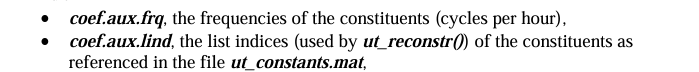
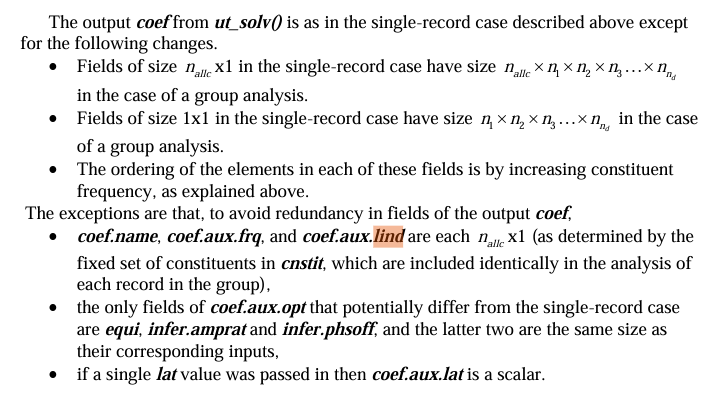

# Are the 'lind' allways the same? I guess so... but let´s check it out!
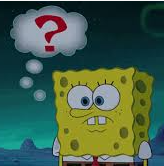

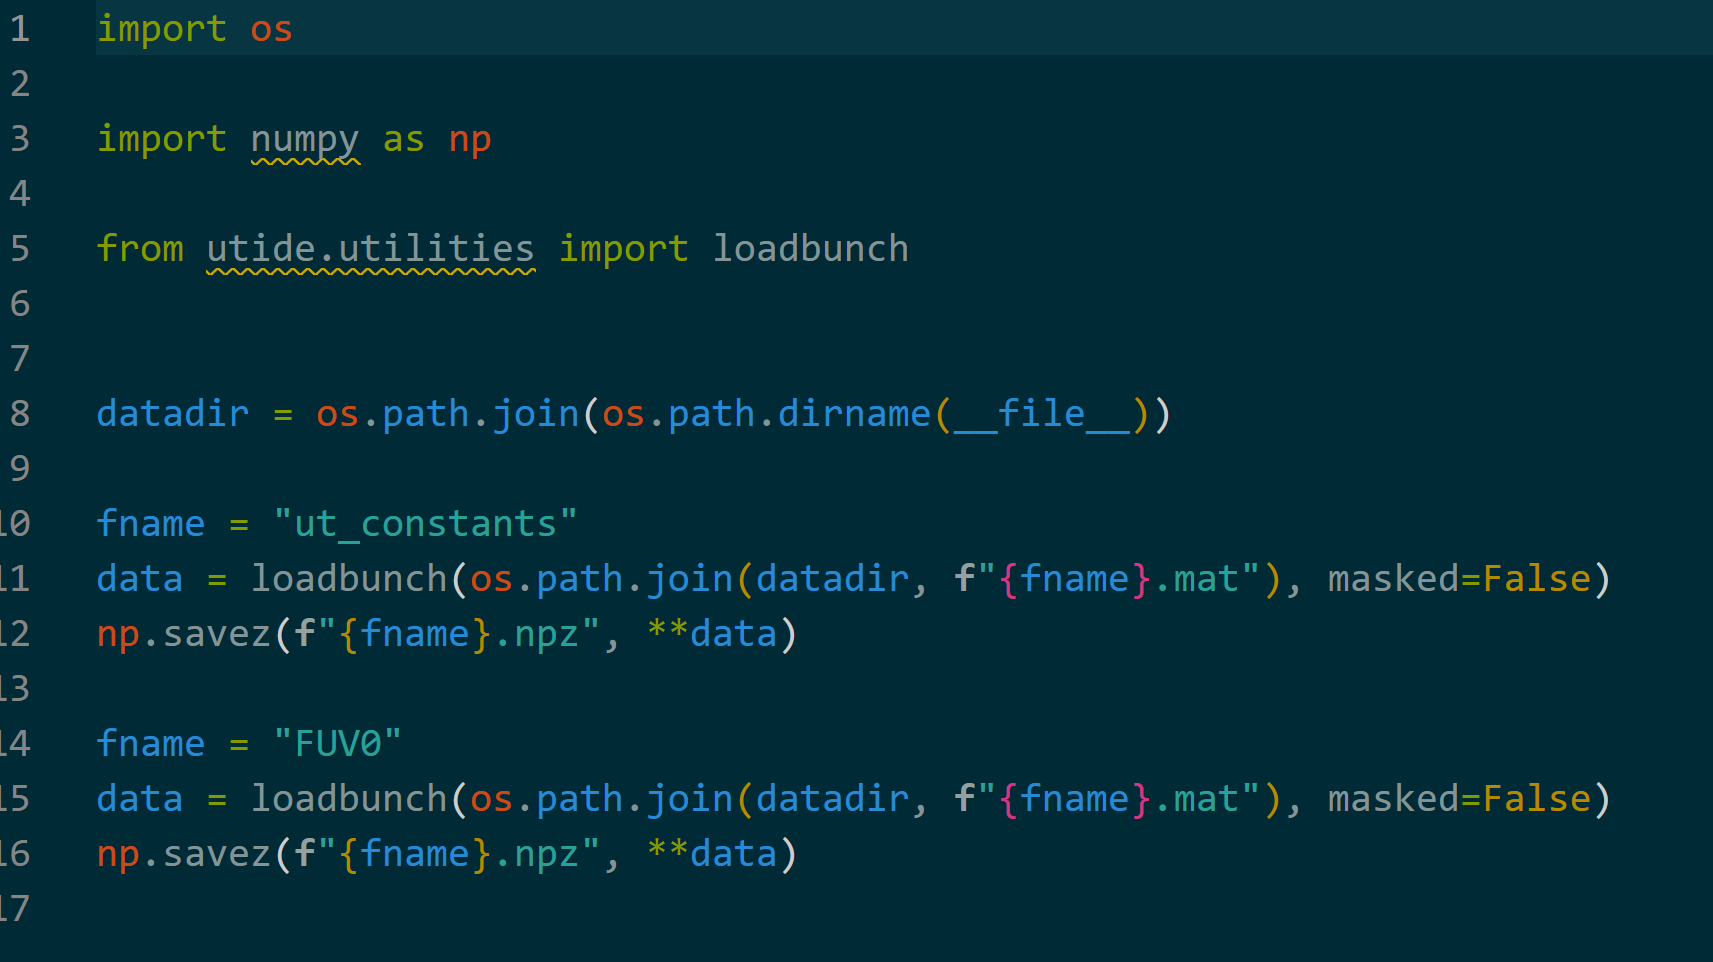

# Opening the Utide tables

In [205]:
path = r'c:\Python311\Lib\site-packages\utide\data\\'

ut_constants = np.load(path + 'ut_constants.npz', allow_pickle=True, encoding='bytes')

ut_constants.files

['ut_version', 'shallow', 'const', 'sat']

In [206]:
x = ut_constants['const'].item()   #Chatgpt... how to access the structure data
print(type(x))
print(x.keys())

names = x[b'name']
freqs = x[b'freq']

print(names[47])
print(freqs[47])

<class 'utide.utilities.Bunch'>
dict_keys([b'ikmpr', b'name', b'semi', b'df', b'kmpr', b'ishallow', b'nshallow', b'nsat', b'doodsonamp', b'doodsonspecies', b'freq', b'isat', b'doodson'])
M2  
0.0805114007


# YES
### The 'lind' is the indice which retrieves information about the harmonic based on a dictionary
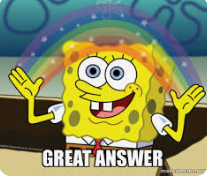

### Manipulating the 'coef' bunch... slicing for the first two constituints, to see what really matters!

prep/calcs ... done.


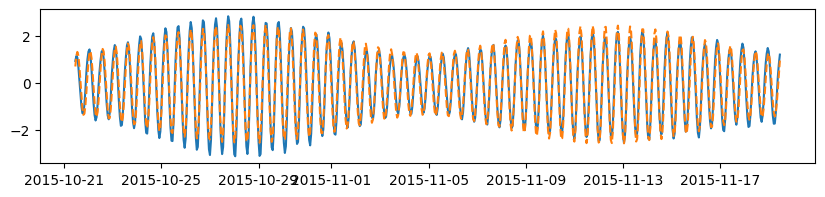

In [207]:
coef2 = copy.deepcopy(coef)

coef2['name'] = np.array(coef['name'][:2])
coef2['A'] = np.array(coef['A'][:2])
coef2['g'] = np.array(coef['g'][:2])
# coef2['weights'] = np.array(coef['weights'][:2])
# coef2['g_ci'] = np.array(coef['g_ci'][:2])
# coef2['A_ci'] = np.array(coef['A_ci'][:2])
coef2['A_ci'] = np.array([0, 0])
coef2['aux']['frq'] = np.array(coef['aux']['frq'][:2])
coef2['aux']['lind'] = np.array(coef['aux']['lind'][:2])

x = utide.reconstruct(time_gmt, coef2)

h_harmonic = x['h']
fig, ax = plt.subplots(figsize=(10,2))
ax.plot(time, h)
ax.plot(time, h_harmonic, '--')

### Using only one constituent

prep/calcs ... done.


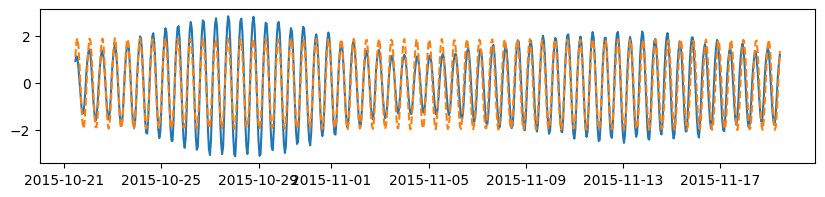

In [208]:
coef2 = copy.deepcopy(coef)

coef2['name'] = np.array(coef['name'][0])
coef2['A'] = np.array(coef['A'][0])
coef2['g'] = np.array(coef['g'][0])
# coef2['weights'] = np.array(coef['weights'][0])
# coef2['g_ci'] = np.array(coef['g_ci'][0])
coef2['A_ci'] = np.array(coef['A_ci'][0])
coef2['aux']['frq'] = np.array(coef['aux']['frq'][0])
coef2['aux']['lind'] = np.array(coef['aux']['lind'][0])

x = utide.reconstruct(time_gmt, coef2)

h_harmonic = x['h']
fig, ax = plt.subplots(figsize=(10,2))
ax.plot(time, h)
ax.plot(time, h_harmonic, '--')

# Now... let´s see if we can do it!
### Tidal constituents for Maputo Bay, Mozambique

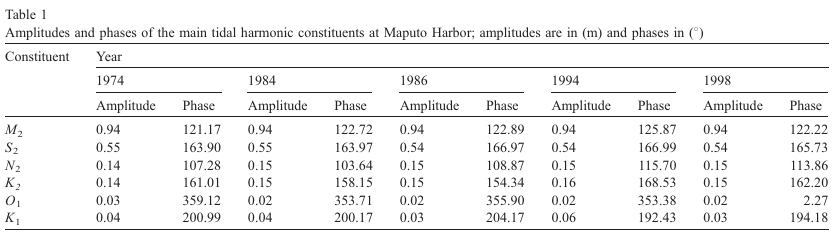

In [209]:
# duplicate the bunch
coef_maputo = copy.deepcopy(coef)

# for 1998
my_names = np.array(['M2', 'S2', 'N2', 'K2', 'O1', 'K1'])
my_A = np.array([0.94, 0.54, 0.15, 0.15, 0.02, 0.03])
my_g = np.array([122.22, 165.73, 113.86, 162.20, 2.27, 194.18])

# First, find the 'freqs' and 'lind' for the constituents from ut_constants (uploaded above)

In [210]:
x = ut_constants['const'].item()   #Chatgpt... how to access the structure data
print(x.keys())

ut_names = x[b'name']
ut_freqs = x[b'freq']

print(ut_names[47])
print(ut_freqs[47])

dict_keys([b'ikmpr', b'name', b'semi', b'df', b'kmpr', b'ishallow', b'nshallow', b'nsat', b'doodsonamp', b'doodsonspecies', b'freq', b'isat', b'doodson'])
M2  
0.0805114007


## Finding the freqs and lints for the constants
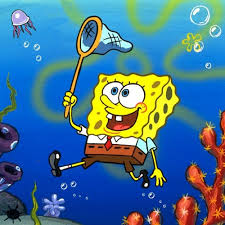

In [211]:
my_lint = []
my_freqs = []
for name in my_names:
    for i, ut_name in enumerate(ut_names):
        if name == ut_name.strip():
            my_lint.append(i)
            my_freqs.append(ut_freqs[i])

print(my_lint)
print(my_freqs)

[47, 56, 41, 58, 12, 20]
[0.0805114007, 0.0833333333, 0.0789992488, 0.0835614924, 0.0387306544, 0.0417807462]


In [212]:
np.zeros_like(my_A)

array([0., 0., 0., 0., 0., 0.])

In [213]:
coef_maputo['name'] = my_names
coef_maputo['A'] = my_A
coef_maputo['g'] = my_g
coef_maputo['A_ci'] = np.zeros_like(my_A)
coef_maputo['aux']['frq'] = np.array(my_freqs)
coef_maputo['aux']['lind'] = np.array(my_lint)

# It works!
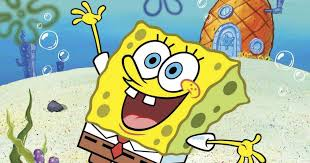

prep/calcs ... done.


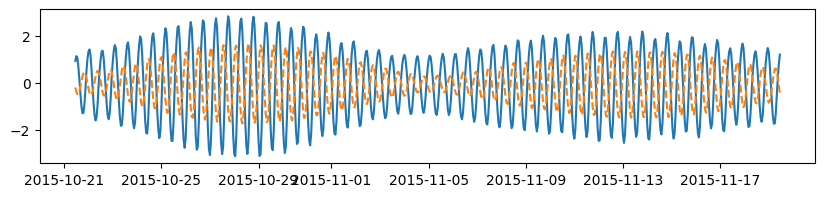

In [214]:
x = utide.reconstruct(time_gmt, coef_maputo)

h_harmonic = x['h']
fig, ax = plt.subplots(figsize=(10,2))
ax.plot(time, h)  # this is Pará
ax.plot(time, h_harmonic, '--') # this is Maputo

# Doing with Maputo Bay water level, from the scratch!

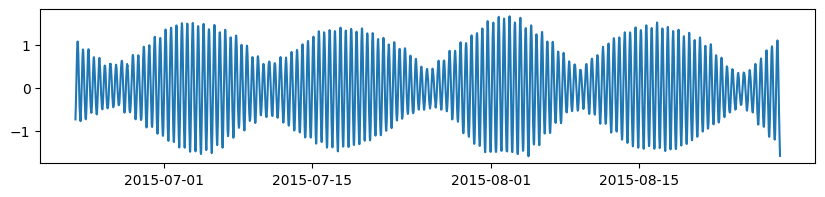

In [215]:
with open('Maputo_waterlevel.pkl', 'rb') as io:
    mwl = pickle.load(io)

m_time = mwl[0]
m_wl = mwl[1] - np.mean(mwl[1])

plt.figure(figsize=(10,2))
plt.plot(m_time, m_wl)

In [216]:
# post done... the date is alredy in GMT! Don´t need correct
m_time_gmt = m_time - datetime.timedelta(hours = 0)

x = utide.reconstruct(m_time_gmt, coef_maputo)

prep/calcs ... done.


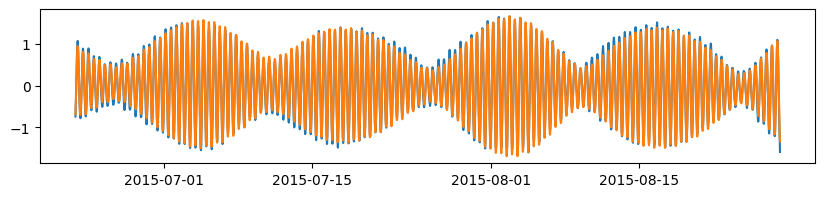

In [217]:
h_harmonic = x['h']

# the water level reconstruct is shifted a little bit...
h_harmonic = h_harmonic - np.mean(h_harmonic)

plt.figure(figsize=(10,2))
plt.plot(m_time, m_wl)
plt.plot(m_time, h_harmonic)

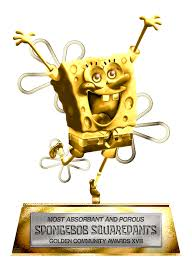

(16611.0, 16631.0)

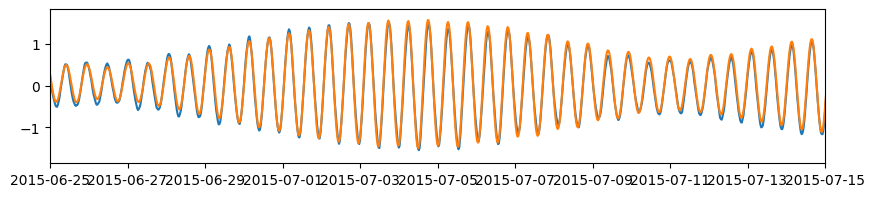

In [218]:
l1 = datetime.datetime(2015, 6, 25)
l2 = datetime.datetime(2015, 7, 15)
plt.figure(figsize=(10,2))
plt.plot(m_time, m_wl)
plt.plot(m_time, h_harmonic)
plt.xlim(l1, l2)

# Final test... creating a minimal 'coef', with true latitude
# However... changing the latitude changes nothing...

solve: matrix prep ... solution ... done.
prep/calcs ... done.


(16611.0, 16631.0)

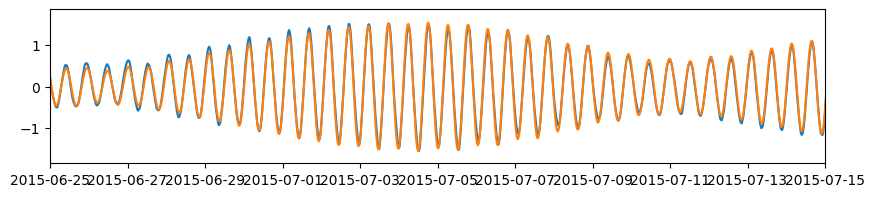

In [228]:
t = np.array([datetime.datetime(2000,1,1,1), datetime.datetime(2000,1,1,2)])
n = np.array([0, 0])
coef_dummy = utide.solve(t, n, v=None, lat=-26)

coef_dummy['name'] = my_names
coef_dummy['A'] = my_A
coef_dummy['g'] = my_g
coef_dummy['A_ci'] = np.zeros_like(my_A)
coef_dummy['aux']['frq'] = np.array(my_freqs)
coef_dummy['aux']['lind'] = np.array(my_lint)

x = utide.reconstruct(m_time_gmt, coef_dummy)

h_harmonic = x['h']
h_harmonic = h_harmonic - np.mean(h_harmonic)

l1 = datetime.datetime(2015, 6, 25)
l2 = datetime.datetime(2015, 7, 15)

plt.figure(figsize=(10,2))
plt.plot(m_time, m_wl)
plt.plot(m_time, h_harmonic)
plt.xlim(l1, l2)

solve: matrix prep ... solution ... done.
prep/calcs ... done.


(16611.0, 16631.0)

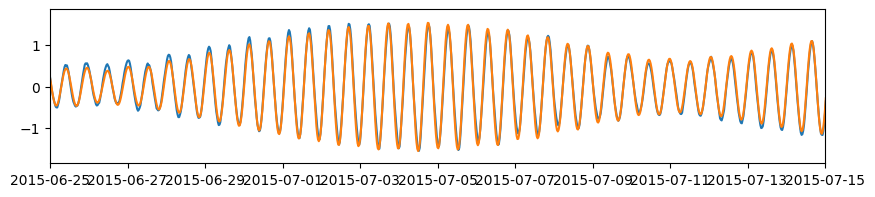

In [232]:
t = np.array([datetime.datetime(2000,1,1,1), datetime.datetime(2000,1,1,2)])
n = np.array([0, 0])
coef_dummy = utide.solve(t, n, v=None, lat=0.1)

coef_dummy['name'] = my_names
coef_dummy['A'] = my_A
coef_dummy['g'] = my_g
coef_dummy['A_ci'] = np.zeros_like(my_A)
coef_dummy['aux']['frq'] = np.array(my_freqs)
coef_dummy['aux']['lind'] = np.array(my_lint)

x = utide.reconstruct(m_time_gmt, coef_dummy)

h_harmonic = x['h']
h_harmonic = h_harmonic - np.mean(h_harmonic)

l1 = datetime.datetime(2015, 6, 25)
l2 = datetime.datetime(2015, 7, 15)

plt.figure(figsize=(10,2))
plt.plot(m_time, m_wl)
plt.plot(m_time, h_harmonic)
plt.xlim(l1, l2)

# Conclusions...
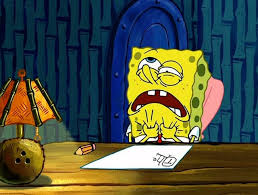
1. It did work!
2. It is not elegant...
3. Who cares?

### Asking to ChatGPT... using the values from the Utide bunch
### "Knowing the amplitude and phase of tidal constituents, how to reconstruct a time series of water level?"
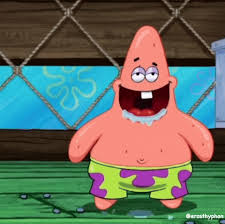  
### Never trust ChatGPT... it is useful, but also dumb!
### It is not so simple as the sum of the cosine function!

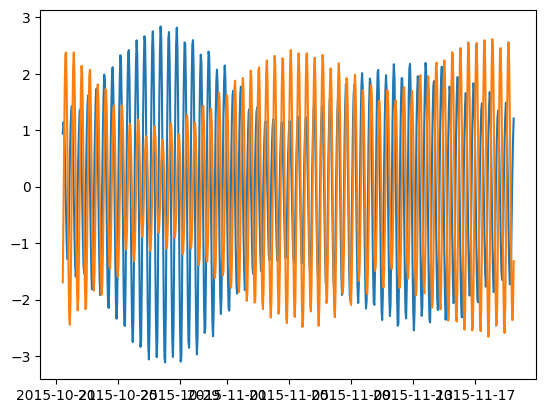

In [219]:
const = {
    'M2': {'A': 1.85, 'phase': 266,  'T': 12.4206},
    'S2': {'A': 0.59, 'phase': 287,  'T': 12.0000},
    'N2': {'A': 0.38, 'phase': 242, 'T': 12.65834},
    'K1': {'A': 0.1, 'phase': 257, 'T': 23.9345},
    'O1': {'A': 0.09, 'phase': 258, 'T': 25.8193},
}

time_n = mdates.date2num(time)*24

eta = np.zeros_like(time_n)

for c in const.values():
    omega = 2*np.pi / c['T']              # rad/h
    phi = np.deg2rad(c['phase'])          # graus → rad
    eta += c['A'] * np.cos(omega*time_n + phi)

plt.plot(time, h)
plt.plot(time, eta)

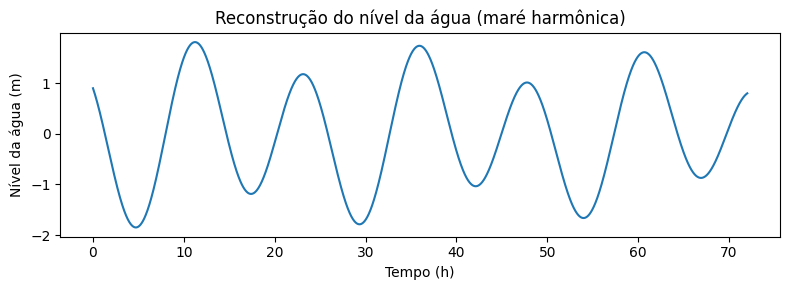

In [220]:
import numpy as np
import matplotlib.pyplot as plt

# Tempo (em horas)
t = np.linspace(0, 72, 72*60)  # 3 dias, resolução de 1 min

# Constituintes
const = {
    'M2': {'A': 1.2, 'phase': 30,  'T': 12.4206},
    'S2': {'A': 0.4, 'phase': 60,  'T': 12.0000},
    'K1': {'A': 0.3, 'phase': 120, 'T': 23.9345},
    'O1': {'A': 0.2, 'phase': 200, 'T': 25.8193},
}

eta = np.zeros_like(t)

for c in const.values():
    omega = 2*np.pi / c['T']              # rad/h
    phi = np.deg2rad(c['phase'])          # graus → rad
    eta += c['A'] * np.cos(omega*t + phi)

# Plot
plt.figure(figsize=(8,3))
plt.plot(t, eta)
plt.xlabel('Tempo (h)')
plt.ylabel('Nível da água (m)')
plt.title('Reconstrução do nível da água (maré harmônica)')
plt.tight_layout()
plt.show()
